# 네트워크 침입 탐지 — MLflow Pipeline v11

## 가설

v6 모델을 재학습하지 않고, Stage-2가 `Infilteration`으로 판단한 행에만 별도의 Stage-1 임계값을 적용하면 DDOS·DoS·Brute Force 성능을 유지하면서 Infilteration Recall을 0.50 이상으로 소폭 높일 수 있다.

- v6 검증 모델과 동일한 250,000행 reservoir 표본 및 클래스별 시간순 80/20 분할을 재현한다.
- 알려진 공격 3종은 v6 임계값 0.45로 고정한다.
- Infilteration 임계값만 0.30~0.45 구간에서 0.0025 간격으로 탐색한다.
- 검증 구간의 앞 절반에서 임계값을 선택하고 뒤 절반에서 시간 홀드아웃 검증한다.
- Recall ≥ 0.50, Precision ≥ 0.08, Accuracy ≥ 0.90, Benign 오탐 ≤ 4,000 조건을 만족할 때만 Registry 승격을 허용한다.


In [1]:
from pathlib import Path
import os
import sys
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from mlflow.models import infer_signature
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

cwd = Path.cwd()
PROJECT_DIR = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(PROJECT_DIR / "src"))
from mlflow_workflow import (
    CHAMPION_ALIAS,
    PROJECT_EXPERIMENT,
    REGISTERED_MODEL_NAME,
    InfilterationThresholdIDSModel,
    configure_tracking,
    file_sha256,
    hypothesis_run,
    log_dataframe_input,
    register_model_version,
)

HYPOTHESIS_ID = "v11"
HYPOTHESIS = "v6_infilteration_specific_threshold_tuning"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

WORK_ROOT = Path("/home/jovyan/work")
DATA_BASE = WORK_ROOT / "datasets"
matches = sorted(DATA_BASE.glob("*/processed/train_temporal_v5.parquet"))
if len(matches) != 1:
    raise RuntimeError(f"Expected one temporal dataset, found: {matches}")
TRAIN_TEMPORAL = matches[0]
TEST_TEMPORAL = TRAIN_TEMPORAL.with_name("test_temporal_v5.parquet")
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "unique_id"
TARGET = "Label"
CAT_FEATURES = ["Dst Port", "Protocol"]
CALENDAR_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "elapsed_hours"]
TRAIN_SAMPLE = 250_000
VALID_FRACTION = 0.20
V6_ATTACK_THRESHOLD = 0.45
INF_THRESHOLDS = np.round(np.arange(0.30, 0.4501, 0.0025), 4)

V6_VALIDATION_RUN_ID = "4dc06735cbfe40f981c74df531adcf8a"
V6_VALIDATION_GATE_URI = "models:/m-71ffa045d7044cbc95e2eb627309f60a"
V6_VALIDATION_SUBTYPE_URI = "models:/m-1eb20bbb39f34e22898c392191eaf13b"
V6_REFIT_RUN_ID = "24bfd469769147f0b3d252f7589bc208"
V6_REFIT_GATE_URI = "models:/m-097892a7ee9e4386821fc0b0f17d8b62"
V6_REFIT_SUBTYPE_URI = "models:/m-ba1f13805e984953976021ee17cfa9af"

V6_BASELINE = {
    "weighted_f1_attacks": 0.9202514012197288,
    "macro_f1_attacks": 0.7541476007767233,
    "accuracy": 0.9089381451548372,
    "infilteration_precision": 0.09265507396833636,
    "infilteration_recall": 0.4594594594594595,
    "infilteration_f1": 0.15421166306695464,
    "benign_to_infilteration_fp": 3496,
    "bruteforce_f1": 0.9204609331084879,
    "ddos_f1": 0.9941826152938201,
    "dos_f1": 0.9477351916376306,
}

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
experiment_id = configure_tracking(MLFLOW_TRACKING_URI, PROJECT_EXPERIMENT)
print("Experiment:", PROJECT_EXPERIMENT, experiment_id)
print("Train     :", TRAIN_TEMPORAL)
print("Output    :", OUTPUT_DIR)
print("Thresholds:", len(INF_THRESHOLDS), INF_THRESHOLDS.min(), "to", INF_THRESHOLDS.max())


Experiment: network-classification-ids 1
Train     : /home/jovyan/work/datasets/ 📁 network-classification/processed/train_temporal_v5.parquet
Output    : /home/jovyan/work/network-classification/outputs/v11
Thresholds: 61 0.3 to 0.45


## 1. v6 표본·시간 분할의 정확한 재현


In [2]:
def parquet_expr(path):
    return f"read_parquet('{str(path).replace(chr(39), chr(39) * 2)}')"

def load_sample(path, rows):
    with duckdb.connect() as con:
        return con.execute(f"""
            SELECT * FROM {parquet_expr(path)}
            USING SAMPLE reservoir({int(rows)} ROWS)
            REPEATABLE ({RANDOM_STATE})
        """).df()

def add_ids_features(df):
    df = df.copy()
    flag_cols = [
        "SYN Flag Cnt", "ACK Flag Cnt", "RST Flag Cnt",
        "FIN Flag Cnt", "URG Flag Cnt", "PSH Flag Cnt",
    ]
    values = {c: pd.to_numeric(df[c], errors="coerce").fillna(0).astype(float) for c in flag_cols}
    syn, ack = values["SYN Flag Cnt"], values["ACK Flag Cnt"]
    rst, fin = values["RST Flag Cnt"], values["FIN Flag Cnt"]
    urg, psh = values["URG Flag Cnt"], values["PSH Flag Cnt"]
    total_flags = syn + ack + rst + fin + urg + psh + 1.0
    df["SYN_ACK_ratio"] = (syn + 1) / (ack + 1)
    df["RST_ACK_ratio"] = (rst + 1) / (ack + 1)
    df["SYN_RST_over_ACK_FIN"] = (syn + rst + 1) / (ack + fin + 1)
    df["ACK_SYN_ratio"] = (ack + 1) / (syn + 1)
    df["URG_ACK_ratio"] = (urg + 1) / (ack + 1)
    df["SYN_share"] = (syn + 1) / total_flags
    df["RST_share"] = (rst + 1) / total_flags
    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].replace([np.inf, -np.inf], np.nan)
    return df

train_df = add_ids_features(load_sample(TRAIN_TEMPORAL, TRAIN_SAMPLE))
train_df["Timestamp"] = pd.to_datetime(train_df["Timestamp"])
y_all = train_df[TARGET].astype(str)
classes = sorted(y_all.unique().tolist())
attack_classes = [label for label in classes if label != "Benign"]
INFILTRATION_LABEL = next(label for label in classes if label.lower() in {"infiltration", "infilteration"})

X_all = train_df.drop(columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES], errors="ignore")
for column in CAT_FEATURES:
    X_all[column] = X_all[column].astype("string")

class_cutoffs = train_df.groupby(TARGET)["Timestamp"].quantile(1 - VALID_FRACTION)
valid_mask = train_df["Timestamp"] > y_all.map(class_cutoffs)
valid_index = train_df.index[valid_mask]
y_valid = y_all.loc[valid_index]

valid_meta = train_df.loc[valid_index, ["Timestamp", TARGET]].copy()
late_cutoffs = valid_meta.groupby(TARGET)["Timestamp"].quantile(0.50)
late_mask = valid_meta["Timestamp"] > valid_meta[TARGET].map(late_cutoffs)
calibration_positions = np.flatnonzero(~late_mask.to_numpy())
late_positions = np.flatnonzero(late_mask.to_numpy())

split_distribution = pd.crosstab(np.where(valid_mask, "valid_late", "train_early"), y_all)
threshold_split = pd.crosstab(np.where(late_mask, "late_holdout", "calibration"), y_valid)
display(class_cutoffs.to_frame("v6_cutoff"))
display(split_distribution)
display(late_cutoffs.to_frame("late_holdout_cutoff"))
display(threshold_split)
print("Rows:", len(train_df), "features:", X_all.shape[1], "validation:", len(valid_index))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,v6_cutoff
Label,
Benign,2018-02-28 11:15:54.000
Brute Force,2018-02-14 11:32:57.200
DDOS,2018-02-21 02:27:14.000
DoS,2018-02-16 10:13:27.000
Infilteration,2018-03-01 03:34:09.000


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
train_early,137495,13146,23894,22345,3132
valid_late,34373,3287,5965,5586,777


,late_holdout_cutoff
Label,
Benign,2018-03-02 04:22:25
Brute Force,2018-02-14 11:51:39
DDOS,2018-02-21 02:30:22
DoS,2018-02-16 10:30:35
Infilteration,2018-03-01 10:24:03


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
calibration,17188,1645,2983,2794,389
late_holdout,17185,1642,2982,2792,388


Rows: 250000 features: 54 validation: 49988


## 2. v6 검증 모델 로드 및 기준 점수 재현


In [3]:
def evaluate(y_true, y_pred):
    result = {
        "weighted_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="weighted", zero_division=0)),
        "macro_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    for label, prefix in [
        (INFILTRATION_LABEL, "infilteration"),
        ("Brute Force", "bruteforce"),
        ("DDOS", "ddos"),
        ("DoS", "dos"),
    ]:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[label], average=None, zero_division=0
        )
        result[f"{prefix}_precision"] = float(precision[0])
        result[f"{prefix}_recall"] = float(recall[0])
        result[f"{prefix}_f1"] = float(f1[0])
    actual, predicted = np.asarray(y_true), np.asarray(y_pred)
    result["benign_to_infilteration_fp"] = int(np.sum(
        (actual == "Benign") & (predicted == INFILTRATION_LABEL)
    ))
    return result

validation_gate = mlflow.sklearn.load_model(V6_VALIDATION_GATE_URI)
validation_subtype = mlflow.sklearn.load_model(V6_VALIDATION_SUBTYPE_URI)
feature_columns = list(validation_gate.feature_names_in_)
X_valid = X_all.loc[valid_index, feature_columns]
gate_probability = validation_gate.predict_proba(X_valid)[:, 1]
subtype_prediction = validation_subtype.predict(X_valid)

def threshold_prediction(infilteration_threshold):
    row_threshold = np.where(
        subtype_prediction == INFILTRATION_LABEL,
        float(infilteration_threshold),
        V6_ATTACK_THRESHOLD,
    )
    return np.where(gate_probability >= row_threshold, subtype_prediction, "Benign")

baseline_prediction = threshold_prediction(V6_ATTACK_THRESHOLD)
baseline_metrics = evaluate(y_valid, baseline_prediction)
for key, expected in V6_BASELINE.items():
    assert np.isclose(baseline_metrics[key], expected, rtol=0, atol=1e-12), (key, baseline_metrics[key], expected)

print("v6 metrics reproduced exactly")
display(pd.DataFrame([baseline_metrics], index=["v6_threshold_0.45"]).T)


v6 metrics reproduced exactly


,v6_threshold_0.45
weighted_f1_attacks,0.920251
macro_f1_attacks,0.754148
accuracy,0.908938
infilteration_precision,0.092655
infilteration_recall,0.459459
infilteration_f1,0.154212
bruteforce_precision,0.855315
bruteforce_recall,0.996349
bruteforce_f1,0.920461
ddos_precision,1.000000


## 3. Infilteration 전용 임계값 미세 탐색

임계값 선택에는 calibration 절반만 사용한다. 전체 검증과 late holdout 점수는 선택 이후의 평가 지표로 취급한다.


In [4]:
def prefixed(metrics, prefix):
    return {f"{prefix}{key}": value for key, value in metrics.items()}

candidate_rows = []
for threshold in INF_THRESHOLDS:
    prediction = threshold_prediction(threshold)
    full_metrics = evaluate(y_valid, prediction)
    calibration_metrics = evaluate(
        y_valid.iloc[calibration_positions], prediction[calibration_positions]
    )
    late_metrics = evaluate(
        y_valid.iloc[late_positions], prediction[late_positions]
    )
    candidate_rows.append({
        "infilteration_threshold": float(threshold),
        **full_metrics,
        **prefixed(calibration_metrics, "calibration_"),
        **prefixed(late_metrics, "late_holdout_"),
    })

search_df = pd.DataFrame(candidate_rows)
search_path = OUTPUT_DIR / "v11_infilteration_threshold_search.csv"
search_df.to_csv(search_path, index=False, encoding="utf-8-sig")

baseline_row = search_df.loc[np.isclose(search_df["infilteration_threshold"], V6_ATTACK_THRESHOLD)].iloc[0]
target_recall = min(0.56, float(baseline_row["calibration_infilteration_recall"]) + 0.035)
search_df["calibration_benign_fp_rate"] = (
    search_df["calibration_benign_to_infilteration_fp"]
    / int((y_valid.iloc[calibration_positions] == "Benign").sum())
)

eligible = search_df[
    (search_df["calibration_infilteration_recall"] >= target_recall)
    & (search_df["calibration_infilteration_recall"] <= 0.56)
    & (search_df["calibration_infilteration_precision"] >= baseline_row["calibration_infilteration_precision"] * 0.90)
    & (search_df["calibration_infilteration_f1"] >= baseline_row["calibration_infilteration_f1"] - 0.005)
    & (search_df["calibration_accuracy"] >= baseline_row["calibration_accuracy"] - 0.015)
    & (search_df["calibration_benign_to_infilteration_fp"] <= baseline_row["calibration_benign_to_infilteration_fp"] * 1.15)
]

if eligible.empty:
    selection_tier = "fallback_nearest_target"
    pool = search_df.copy()
    pool["target_distance"] = (pool["calibration_infilteration_recall"] - 0.50).abs()
    selected = pool.sort_values(["target_distance", "infilteration_threshold"], ascending=[True, False]).iloc[0]
else:
    selection_tier = "strict_minimum_change"
    selected = eligible.sort_values(
        ["infilteration_threshold", "calibration_infilteration_f1"], ascending=False
    ).iloc[0]

selected_threshold = float(selected["infilteration_threshold"])
selected_prediction = threshold_prediction(selected_threshold)
selected_metrics = evaluate(y_valid, selected_prediction)
baseline_late_metrics = evaluate(
    y_valid.iloc[late_positions], baseline_prediction[late_positions]
)
selected_late_metrics = evaluate(
    y_valid.iloc[late_positions], selected_prediction[late_positions]
)

print("Selection tier    :", selection_tier)
print("Selected threshold:", selected_threshold)
print("Calibration target:", target_recall)
display(search_df.sort_values("infilteration_threshold", ascending=False)[[
    "infilteration_threshold",
    "calibration_infilteration_precision", "calibration_infilteration_recall", "calibration_infilteration_f1",
    "infilteration_precision", "infilteration_recall", "infilteration_f1",
    "accuracy", "benign_to_infilteration_fp",
]].head(30))


Selection tier    : strict_minimum_change
Selected threshold: 0.395
Calibration target: 0.4103213367609254


,infilteration_threshold,calibration_infilteration_precision,calibration_infilteration_recall,calibration_infilteration_f1,infilteration_precision,infilteration_recall,infilteration_f1,accuracy,benign_to_infilteration_fp
60,0.4500,0.040612,0.375321,0.073293,0.092655,0.459459,0.154212,0.908938,3496
59,0.4475,0.040398,0.375321,0.072945,0.092435,0.460746,0.153978,0.908578,3515
58,0.4450,0.040220,0.375321,0.072655,0.092055,0.460746,0.153450,0.908258,3531
57,0.4425,0.040022,0.375321,0.072331,0.091630,0.460746,0.152861,0.907898,3549
56,0.4400,0.039902,0.375321,0.072134,0.091350,0.460746,0.152470,0.907658,3561
55,0.4375,0.039946,0.377892,0.072254,0.091094,0.462033,0.152183,0.907258,3582
54,0.4350,0.039773,0.377892,0.071971,0.091162,0.464607,0.152417,0.906958,3599
53,0.4325,0.039612,0.377892,0.071707,0.090818,0.464607,0.151936,0.906658,3614
52,0.4300,0.039495,0.377892,0.071515,0.090772,0.465894,0.151941,0.906438,3626
51,0.4275,0.039572,0.380463,0.071688,0.090614,0.467181,0.151788,0.906117,3643


## 4. 전체 검증·late holdout 및 승격 조건


In [5]:
known_attack_unchanged = all(
    np.isclose(selected_metrics[f"{label}_f1"], V6_BASELINE[f"{label}_f1"], atol=1e-12)
    for label in ["bruteforce", "ddos", "dos"]
)

promotion_checks = {
    "full_recall_at_least_0_50": selected_metrics["infilteration_recall"] >= 0.50,
    "full_recall_gain_at_least_0_02": selected_metrics["infilteration_recall"] >= V6_BASELINE["infilteration_recall"] + 0.02,
    "full_precision_at_least_0_08": selected_metrics["infilteration_precision"] >= 0.08,
    "full_f1_drop_within_0_005": selected_metrics["infilteration_f1"] >= V6_BASELINE["infilteration_f1"] - 0.005,
    "full_accuracy_at_least_0_90": selected_metrics["accuracy"] >= 0.90,
    "full_false_positives_at_most_4000": selected_metrics["benign_to_infilteration_fp"] <= 4000,
    "late_recall_improved": selected_late_metrics["infilteration_recall"] > baseline_late_metrics["infilteration_recall"],
    "late_precision_at_least_0_08": selected_late_metrics["infilteration_precision"] >= 0.08,
    "late_f1_drop_within_0_01": selected_late_metrics["infilteration_f1"] >= baseline_late_metrics["infilteration_f1"] - 0.01,
    "known_attack_f1_unchanged": known_attack_unchanged,
}
hypothesis_supported = all(promotion_checks.values())

comparison_df = pd.DataFrame([
    {"model": "v6_threshold_0.45", **baseline_metrics},
    {"model": f"v11_inf_threshold_{selected_threshold:g}", **selected_metrics},
])
comparison_path = OUTPUT_DIR / "v11_champion_summary.csv"
comparison_df.to_csv(comparison_path, index=False, encoding="utf-8-sig")

holdout_df = pd.DataFrame([
    {"model": "v6_threshold_0.45", **baseline_late_metrics},
    {"model": f"v11_inf_threshold_{selected_threshold:g}", **selected_late_metrics},
])
holdout_path = OUTPUT_DIR / "v11_late_holdout_summary.csv"
holdout_df.to_csv(holdout_path, index=False, encoding="utf-8-sig")

checks_df = pd.DataFrame({"check": promotion_checks.keys(), "passed": promotion_checks.values()})
checks_path = OUTPUT_DIR / "v11_promotion_checks.csv"
checks_df.to_csv(checks_path, index=False, encoding="utf-8-sig")

display(comparison_df)
display(holdout_df)
display(checks_df)
print("Hypothesis supported:", hypothesis_supported)


,model,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp
0,v6_threshold_0.45,0.920251,0.754148,0.908938,0.092655,0.459459,0.154212,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,3496
1,v11_inf_threshold_0.395,0.920264,0.754209,0.901856,0.091271,0.501931,0.154455,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,3883


,model,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp
0,v6_threshold_0.45,0.954290,0.887806,0.980471,0.817829,0.543814,0.653251,0.899062,0.992692,0.94356,1.0,0.976861,0.988295,1.0,0.934456,0.966117,47
1,v11_inf_threshold_0.395,0.955348,0.893123,0.980591,0.786942,0.590206,0.674521,0.899062,0.992692,0.94356,1.0,0.976861,0.988295,1.0,0.934456,0.966117,62


,check,passed
0,full_recall_at_least_0_50,True
1,full_recall_gain_at_least_0_02,True
2,full_precision_at_least_0_08,True
3,full_f1_drop_within_0_005,True
4,full_accuracy_at_least_0_90,True
5,full_false_positives_at_most_4000,True
6,late_recall_improved,True
7,late_precision_at_least_0_08,True
8,late_f1_drop_within_0_01,True
9,known_attack_f1_unchanged,True


Hypothesis supported: True


## 5. 평가 산출물


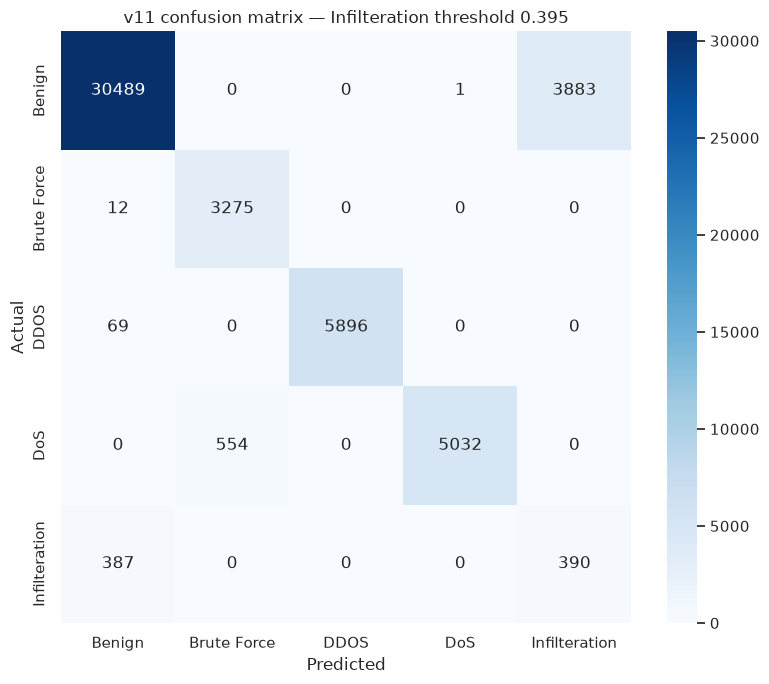

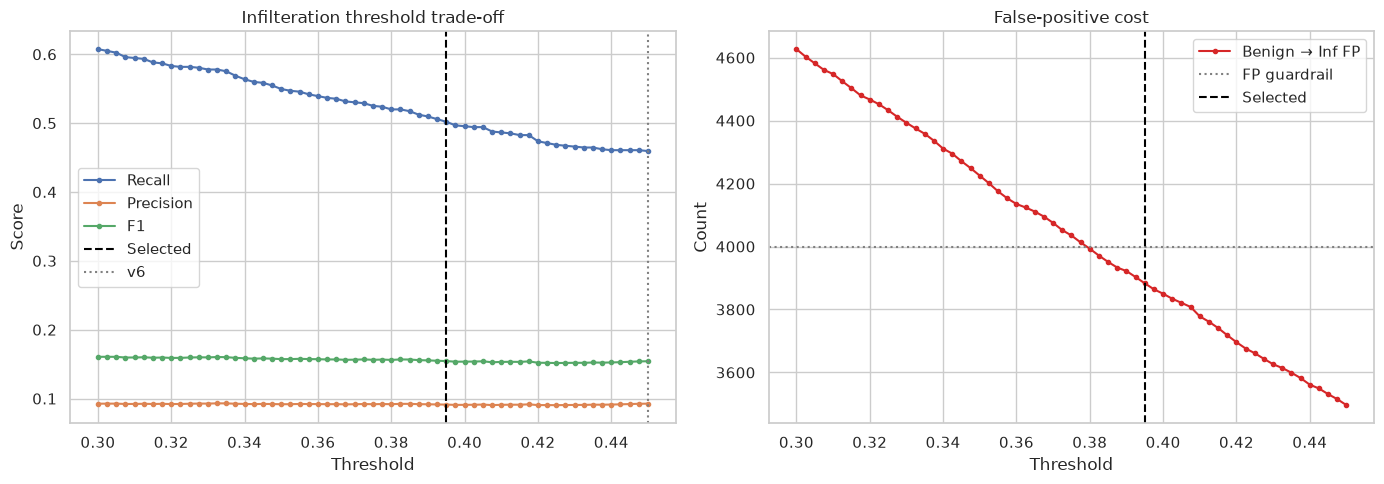

In [6]:
report_path = OUTPUT_DIR / "v11_selected_classification_report.csv"
pd.DataFrame(classification_report(
    y_valid, selected_prediction, labels=classes, output_dict=True, zero_division=0
)).T.to_csv(report_path, encoding="utf-8-sig")

cm = confusion_matrix(y_valid, selected_prediction, labels=classes)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set(title=f"v11 confusion matrix — Infilteration threshold {selected_threshold:g}", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
cm_path = OUTPUT_DIR / "v11_selected_confusion_matrix.png"
fig.savefig(cm_path, dpi=140, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(search_df["infilteration_threshold"], search_df["infilteration_recall"], marker=".", label="Recall")
axes[0].plot(search_df["infilteration_threshold"], search_df["infilteration_precision"], marker=".", label="Precision")
axes[0].plot(search_df["infilteration_threshold"], search_df["infilteration_f1"], marker=".", label="F1")
axes[0].axvline(selected_threshold, color="black", linestyle="--", label="Selected")
axes[0].axvline(V6_ATTACK_THRESHOLD, color="gray", linestyle=":", label="v6")
axes[0].set(title="Infilteration threshold trade-off", xlabel="Threshold", ylabel="Score")
axes[0].legend()
axes[1].plot(search_df["infilteration_threshold"], search_df["benign_to_infilteration_fp"], marker=".", color="tab:red", label="Benign → Inf FP")
axes[1].axhline(4000, color="gray", linestyle=":", label="FP guardrail")
axes[1].axvline(selected_threshold, color="black", linestyle="--", label="Selected")
axes[1].set(title="False-positive cost", xlabel="Threshold", ylabel="Count")
axes[1].legend()
plt.tight_layout()
tradeoff_path = OUTPUT_DIR / "v11_threshold_tradeoff.png"
fig.savefig(tradeoff_path, dpi=140, bbox_inches="tight")
plt.show()


## 6. 표준 MLflow parent/child 기록


In [7]:
notebook_path = cwd / "code_mlflow_pipeline_v11.ipynb"
code_version = file_sha256(notebook_path) if notebook_path.exists() else "unavailable"
lineage_sample = train_df.iloc[:2000].copy()
lineage_numeric = lineage_sample.select_dtypes(include=[np.number]).columns
lineage_sample[lineage_numeric] = lineage_sample[lineage_numeric].astype(float)

with hypothesis_run(
    run_name="v11_infilteration_threshold_validation",
    hypothesis_id=HYPOTHESIS_ID,
    hypothesis=HYPOTHESIS,
    stage="chronological_validation",
    promotion_status="candidate" if hypothesis_supported else "rejected",
    validation_strategy="v6_within_class_80_20_plus_late_half_holdout",
    notebook=notebook_path.name,
    data_version=TRAIN_TEMPORAL.name,
    feature_schema_version="v5-temporal-2-v6-model-frozen",
    code_version=code_version,
    extra_tags={
        "champion_remains": "v11" if hypothesis_supported else "v6",
        "source_v6_validation_run_id": V6_VALIDATION_RUN_ID,
        "model_change": "infilteration_threshold_only",
    },
) as parent_run:
    mlflow.log_params({
        "v6_attack_threshold": V6_ATTACK_THRESHOLD,
        "selected_infilteration_threshold": selected_threshold,
        "threshold_min": float(INF_THRESHOLDS.min()),
        "threshold_max": float(INF_THRESHOLDS.max()),
        "threshold_step": 0.0025,
        "threshold_candidates": len(INF_THRESHOLDS),
        "selection_tier": selection_tier,
        "source_v6_validation_run_id": V6_VALIDATION_RUN_ID,
        "source_v6_refit_run_id": V6_REFIT_RUN_ID,
        "training_data_sha256": file_sha256(TRAIN_TEMPORAL),
    })
    parent_metrics = {**selected_metrics}
    parent_metrics.update({f"delta_vs_v6_{k}": float(selected_metrics[k] - baseline_metrics[k]) for k in [
        "accuracy", "infilteration_precision", "infilteration_recall", "infilteration_f1", "benign_to_infilteration_fp"
    ]})
    parent_metrics.update({f"late_holdout_{k}": float(v) for k, v in selected_late_metrics.items()})
    parent_metrics["promotion_checks_passed"] = float(sum(promotion_checks.values()))
    mlflow.log_metrics({key: float(value) for key, value in parent_metrics.items()})
    log_dataframe_input(
        lineage_sample, source=TRAIN_TEMPORAL,
        name="train_temporal_v5_sample", context="threshold_validation", targets=TARGET,
    )
    for artifact in [search_path, comparison_path, holdout_path, checks_path, report_path, cm_path, tradeoff_path]:
        mlflow.log_artifact(str(artifact))
    mlflow.log_artifact(str(notebook_path), artifact_path="code")

    candidate_thresholds = {
        V6_ATTACK_THRESHOLD,
        selected_threshold,
        float(search_df.loc[search_df["infilteration_f1"].idxmax(), "infilteration_threshold"]),
    }
    for recall_target in [0.50, 0.525, 0.55]:
        index = (search_df["infilteration_recall"] - recall_target).abs().idxmin()
        candidate_thresholds.add(float(search_df.loc[index, "infilteration_threshold"]))
    for threshold in sorted(candidate_thresholds, reverse=True):
        row = search_df.loc[np.isclose(search_df["infilteration_threshold"], threshold)].iloc[0]
        with mlflow.start_run(run_name=f"v11_threshold_{threshold:g}", nested=True):
            mlflow.set_tags({"hypothesis_id": HYPOTHESIS_ID, "stage": "threshold_candidate", "threshold_only": "true"})
            mlflow.log_param("infilteration_threshold", threshold)
            metric_columns = [
                "weighted_f1_attacks", "macro_f1_attacks", "accuracy",
                "infilteration_precision", "infilteration_recall", "infilteration_f1",
                "benign_to_infilteration_fp",
                "calibration_infilteration_precision", "calibration_infilteration_recall", "calibration_infilteration_f1",
                "late_holdout_infilteration_precision", "late_holdout_infilteration_recall", "late_holdout_infilteration_f1",
            ]
            mlflow.log_metrics({column: float(row[column]) for column in metric_columns})
    validation_run_id = parent_run.info.run_id

print("Validation run:", validation_run_id)


🏃 View run v11_threshold_0.45 at: http://mlflow:5000/#/experiments/1/runs/1df0bcfad1e14c91b5733024f43b66b7
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v11_threshold_0.395 at: http://mlflow:5000/#/experiments/1/runs/e32419578c154175b57b38d722776b00
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v11_threshold_0.375 at: http://mlflow:5000/#/experiments/1/runs/c8db0694c9cf4fcca81f72409713deee
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v11_threshold_0.35 at: http://mlflow:5000/#/experiments/1/runs/076363b7bddf46f2931a482132c43020
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v11_threshold_0.3025 at: http://mlflow:5000/#/experiments/1/runs/0f98d206560a4a3388ba75d8cfcfd459
🧪 View experiment at: http://mlflow:5000/#/experiments/1
🏃 View run v11_infilteration_threshold_validation at: http://mlflow:5000/#/experiments/1/runs/8eba7dd397e448e8a2155efd72e0569b
🧪 View experiment at: http://mlflow:5000/#/experiments/1
Validation run: 8eba7dd397e448e8a2155efd72e0569b


## 7. 조건부 Registry 승격

승격 시에도 v6의 전체 재학습 모델을 그대로 사용하고 PyFunc의 Infilteration 전용 임계값만 교체한다.


In [8]:
final_run_id = None
registry_version = None
submission_path = None

if hypothesis_supported:
    final_gate = mlflow.sklearn.load_model(V6_REFIT_GATE_URI)
    final_subtype = mlflow.sklearn.load_model(V6_REFIT_SUBTYPE_URI)
    final_feature_columns = list(final_gate.feature_names_in_)
    composite = InfilterationThresholdIDSModel(
        final_gate,
        final_subtype,
        attack_threshold=V6_ATTACK_THRESHOLD,
        infilteration_threshold=selected_threshold,
        feature_columns=final_feature_columns,
    )
    input_example = X_all.loc[:, final_feature_columns].iloc[:5].copy()
    output_example = composite.predict(None, input_example)
    signature = infer_signature(input_example, output_example)

    with hypothesis_run(
        run_name="v11_threshold_only_repackage",
        hypothesis_id=HYPOTHESIS_ID,
        hypothesis=HYPOTHESIS,
        stage="refit",
        promotion_status="champion",
        validation_strategy="approved_v11_threshold_validation",
        notebook=notebook_path.name,
        data_version=TRAIN_TEMPORAL.name,
        feature_schema_version="v5-temporal-2-v6-model-frozen",
        code_version=file_sha256(notebook_path),
        extra_tags={
            "source_validation_run_id": validation_run_id,
            "source_v6_refit_run_id": V6_REFIT_RUN_ID,
            "model_change": "infilteration_threshold_only",
        },
    ) as final_run:
        mlflow.log_params({
            "attack_threshold": V6_ATTACK_THRESHOLD,
            "infilteration_threshold": selected_threshold,
            "source_validation_run_id": validation_run_id,
            "source_v6_refit_run_id": V6_REFIT_RUN_ID,
        })
        mlflow.log_metrics({key: float(value) for key, value in selected_metrics.items()})
        log_dataframe_input(
            lineage_sample, source=TRAIN_TEMPORAL,
            name="train_temporal_v5_sample", context="threshold_only_repackage", targets=TARGET,
        )
        model_info = mlflow.pyfunc.log_model(
            name="network_classifier",
            python_model=composite,
            input_example=input_example,
            signature=signature,
            code_paths=[str(PROJECT_DIR / "src" / "mlflow_workflow.py")],
            metadata={
                "attack_threshold": V6_ATTACK_THRESHOLD,
                "infilteration_threshold": selected_threshold,
                "source_v6_refit_run_id": V6_REFIT_RUN_ID,
            },
        )
        version = register_model_version(
            model_uri=model_info.model_uri,
            version_tags={
                "validation_status": "passed",
                "hypothesis_id": HYPOTHESIS_ID,
                "source_validation_run_id": validation_run_id,
                "source_v6_refit_run_id": V6_REFIT_RUN_ID,
                "model_change": "infilteration_threshold_only",
            },
            registered_model_tags={
                "project": "network-classification",
                "task": "multiclass-classification",
                "architecture": "hierarchical_pyfunc_separate_infilteration_threshold",
            },
        )
        final_run_id = final_run.info.run_id
        registry_version = version.version

    with duckdb.connect() as con:
        test_df = con.execute(f"SELECT * FROM {parquet_expr(TEST_TEMPORAL)}").df()
    test_df = add_ids_features(test_df)
    test_ids = test_df[ID_COL].copy()
    X_test = test_df.drop(columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES], errors="ignore")
    for column in CAT_FEATURES:
        X_test[column] = X_test[column].astype("string")
    test_prediction = composite.predict(None, X_test.loc[:, final_feature_columns])[TARGET].to_numpy()
    submission = pd.DataFrame({ID_COL: test_ids, TARGET: test_prediction}).set_index(ID_COL)
    submission_path = OUTPUT_DIR / "submission_v11.csv"
    submission.to_csv(submission_path, encoding="utf-8-sig")
    status_path = OUTPUT_DIR / "APPROVED.md"
    status_path.write_text(
        "# v11 experiment status: approved\n\n"
        f"- Infilteration threshold: {selected_threshold}\n"
        f"- Precision / Recall / F1: {selected_metrics['infilteration_precision']:.6f} / {selected_metrics['infilteration_recall']:.6f} / {selected_metrics['infilteration_f1']:.6f}\n"
        f"- Accuracy: {selected_metrics['accuracy']:.6f}; false positives: {int(selected_metrics['benign_to_infilteration_fp'])}\n"
        f"- Validation run: `{validation_run_id}`\n"
        f"- Registry version: `{registry_version}`\n",
        encoding="utf-8",
    )
else:
    status_path = OUTPUT_DIR / "REJECTED.md"
    failed_checks = [name for name, passed in promotion_checks.items() if not passed]
    status_path.write_text(
        "# v11 experiment status: rejected\n\n"
        "v6 remains the Registry champion.\n\n"
        f"- Selected Infilteration threshold: {selected_threshold}\n"
        f"- Precision / Recall / F1: {selected_metrics['infilteration_precision']:.6f} / {selected_metrics['infilteration_recall']:.6f} / {selected_metrics['infilteration_f1']:.6f}\n"
        f"- Accuracy: {selected_metrics['accuracy']:.6f}; false positives: {int(selected_metrics['benign_to_infilteration_fp'])}\n"
        f"- Failed checks: {', '.join(failed_checks)}\n"
        f"- Validation run: `{validation_run_id}`\n",
        encoding="utf-8",
    )

print("Status          :", "approved" if hypothesis_supported else "rejected")
print("Status file     :", status_path)
print("Final run       :", final_run_id)
print("Registry version:", registry_version)
print("Submission      :", submission_path)


2026/08/17 11:13:45 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/08/17 11:13:45 INFO mlflow.pyfunc: Validating input example against model signature


Registered model 'network-classification-ids' already exists. Creating a new version of this model...
2026/08/17 11:13:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: network-classification-ids, version 2


Created version '2' of model 'network-classification-ids'.


🏃 View run v11_threshold_only_repackage at: http://mlflow:5000/#/experiments/1/runs/0af56f14287843e29eaae573ef575c12
🧪 View experiment at: http://mlflow:5000/#/experiments/1


Status          : approved
Status file     : /home/jovyan/work/network-classification/outputs/v11/APPROVED.md
Final run       : 0af56f14287843e29eaae573ef575c12
Registry version: 2
Submission      : /home/jovyan/work/network-classification/outputs/v11/submission_v11.csv
